# Comprehensive Multi-Layer Spectral Analysis (5 Layers)
Analysis of **AST, CFG, DDG, PDG, and CPG** layers.
- **Section 1**: Global Mean Score comparison across all layers.
- **Section 2**: Detailed Comparison Table (Clones vs Non-Clones).
- **Section 3**: Individual Layer Distributions.


label,0,1
layer,,
AST,0.7950,0.7999
CFG,0.7459,0.7525
CPG,0.8218,0.8254
DDG,0.7818,0.7897
PDG,0.7835,0.7892


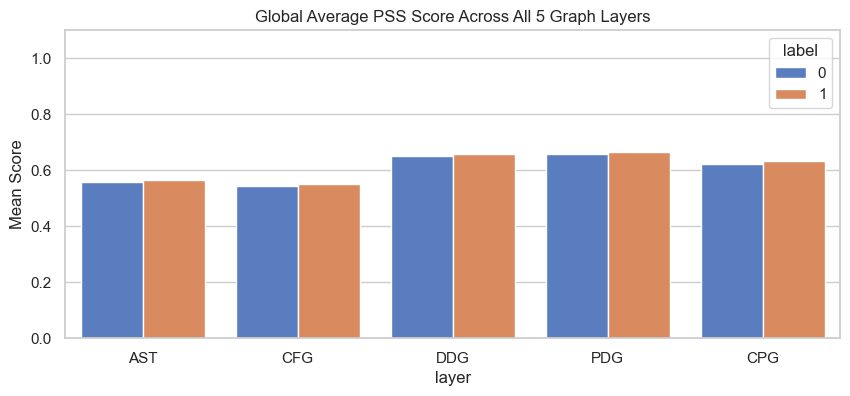

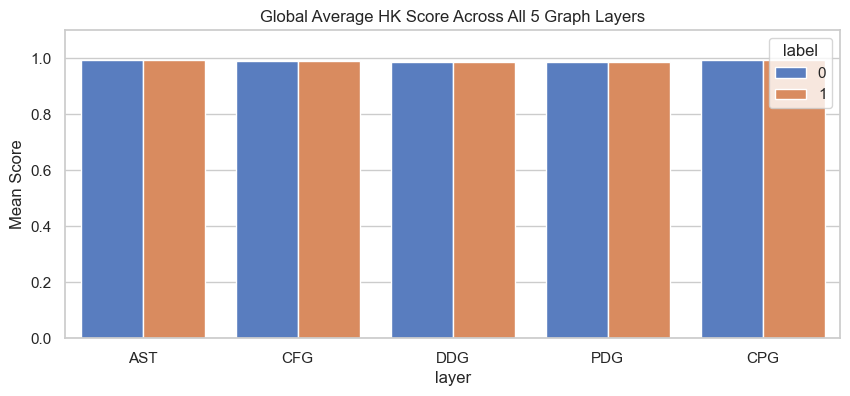

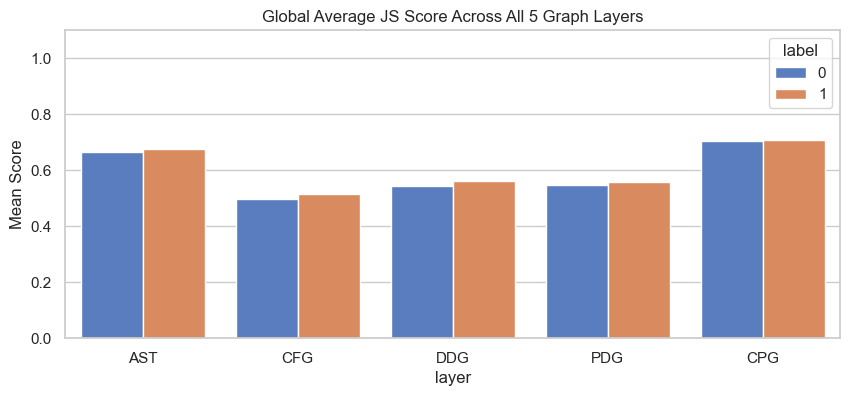

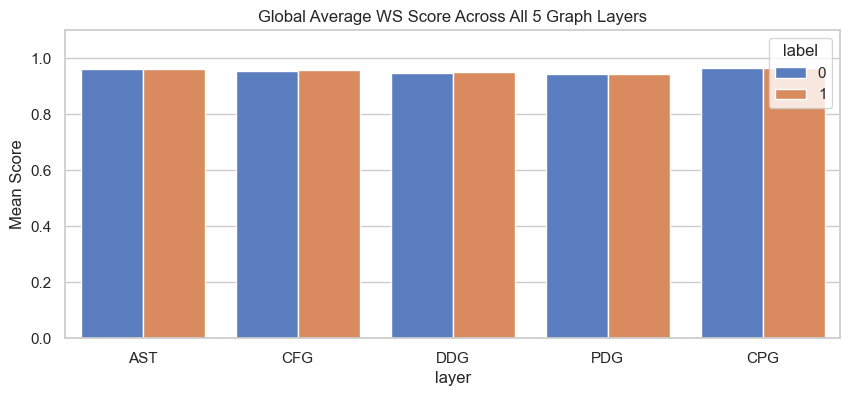

,pair_ids,label,cfg_n1,cfg_n2,pss_cfg,hk_cfg,pss_ast,hk_ast,pss_cpg
1712,20675046_6008635,0,32,24,0.7374,0.9823,0.8347,0.9901,0.8682
4655,22410173_18211588,1,21,34,0.5911,0.9941,0.7477,0.9943,0.8006
1251,9272325_13063241,0,31,16,0.4984,0.9862,0.5473,0.9919,0.6224
634,4852691_10391753,1,15,32,0.4669,0.9969,0.4522,0.9906,0.5323
2204,12097948_23008590,0,28,64,0.4450,0.9932,0.5356,0.9978,0.6050
4127,14473781_19868933,0,49,19,0.4109,0.9915,0.5344,0.9954,0.6073
1901,21152728_5759961,1,116,34,0.3570,0.9943,0.3690,0.9973,0.4647
2251,15797402_9109613,1,17,71,0.3414,0.9871,0.3451,0.9875,0.4466
428,14001795_8079516,1,73,315,0.3342,0.9923,0.3285,0.9983,0.4344
1995,8953394_21033686,0,12,61,0.3170,0.9944,0.3292,0.9941,0.4228


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML

# Config
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = [16, 8]
data_path = Path("../data/comprehensive_multi_layer_analysis.csv")

# Load data
df = pd.read_csv(data_path)
layers = ["ast", "cfg", "ddg", "pdg", "cpg"]

def get_layer_stats():
    all_stats = []
    for layer in layers:
        metrics = [f'pss_{layer}', f'hk_{layer}', f'js_{layer}', f'ws_{layer}']
        # Compute mean for clones and non-clones
        stats = df.groupby('label')[metrics].mean().reset_index()
        stats['layer'] = layer.upper()
        # Melt to make it long-form for plotting
        stats_melted = stats.melt(id_vars=['layer', 'label'], var_name='Metric', value_name='Mean Score')
        all_stats.append(stats_melted)
    return pd.concat(all_stats, ignore_index=True)

def plot_layer_analysis(layer):
    display(HTML(f"<hr><h2>Detailed Analysis: {layer.upper()} Layer</h2>"))
    layer_df = df.dropna(subset=[f"pss_{layer}"])
    metrics = [f'pss_{layer}', f'hk_{layer}', f'js_{layer}', f'ws_{layer}']
    
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    for i, m in enumerate(metrics):
        sns.kdeplot(data=layer_df, x=m, hue='label', fill=True, ax=axes[i])
        axes[i].set_title(f"{m.split('_')[0].upper()}")
    plt.tight_layout()
    plt.show()

# --- SECTION 1: GLOBAL OVERVIEW ---
display(HTML("<h1>Section 1: Global Mean Comparison</h1>"))
global_stats = get_layer_stats()

# Display mean scores in a single clean table formatted for readability
display(HTML("<h3>Summary Table: Mean Scores per Layer (Clones vs Non-Clones)</h3>"))
summary_view = global_stats.pivot_table(index='layer', columns='label', values='Mean Score', aggfunc='mean')
display(summary_view.style.format("{:.4f}").background_gradient(axis=1, cmap='YlGn'))

# Filter for easier view
for m_type in ['PSS', 'HK', 'JS', 'WS']:
    plt.figure(figsize=(10, 4))
    m_data = global_stats[global_stats['Metric'].str.startswith(m_type.lower())]
    sns.barplot(data=m_data, x='layer', y='Mean Score', hue='label')
    plt.title(f"Global Average {m_type} Score Across All 5 Graph Layers")
    plt.ylim(0, 1.1)
    plt.show()

# --- SECTION 2: SAMPLE PAIR COMPARISON ---
display(HTML("<h1>Section 2: Sample Pair Comparison (Clones vs Non-Clones)</h1>"))
clones = df[df['label'] == 1].sample(5, random_state=42)
non_clones = df[df['label'] == 0].sample(5, random_state=42)

# High Similarity Samples (Similar)
display(HTML("<h3>High Similarity Pair Examples (Sorted by PSS CFG Score)</h3>"))
samples = pd.concat([clones, non_clones])
table_cols = ['pair_ids', 'label', 'cfg_n1', 'cfg_n2', 'pss_cfg', 'hk_cfg', 'pss_ast', 'hk_ast', 'pss_cpg']
display(samples[table_cols].sort_values('pss_cfg', ascending=False).style.background_gradient(cmap='Greens', subset=['pss_cfg', 'pss_ast', 'pss_cpg']).format("{:.4f}", subset=['pss_cfg', 'hk_cfg', 'pss_ast', 'hk_ast', 'pss_cpg']))


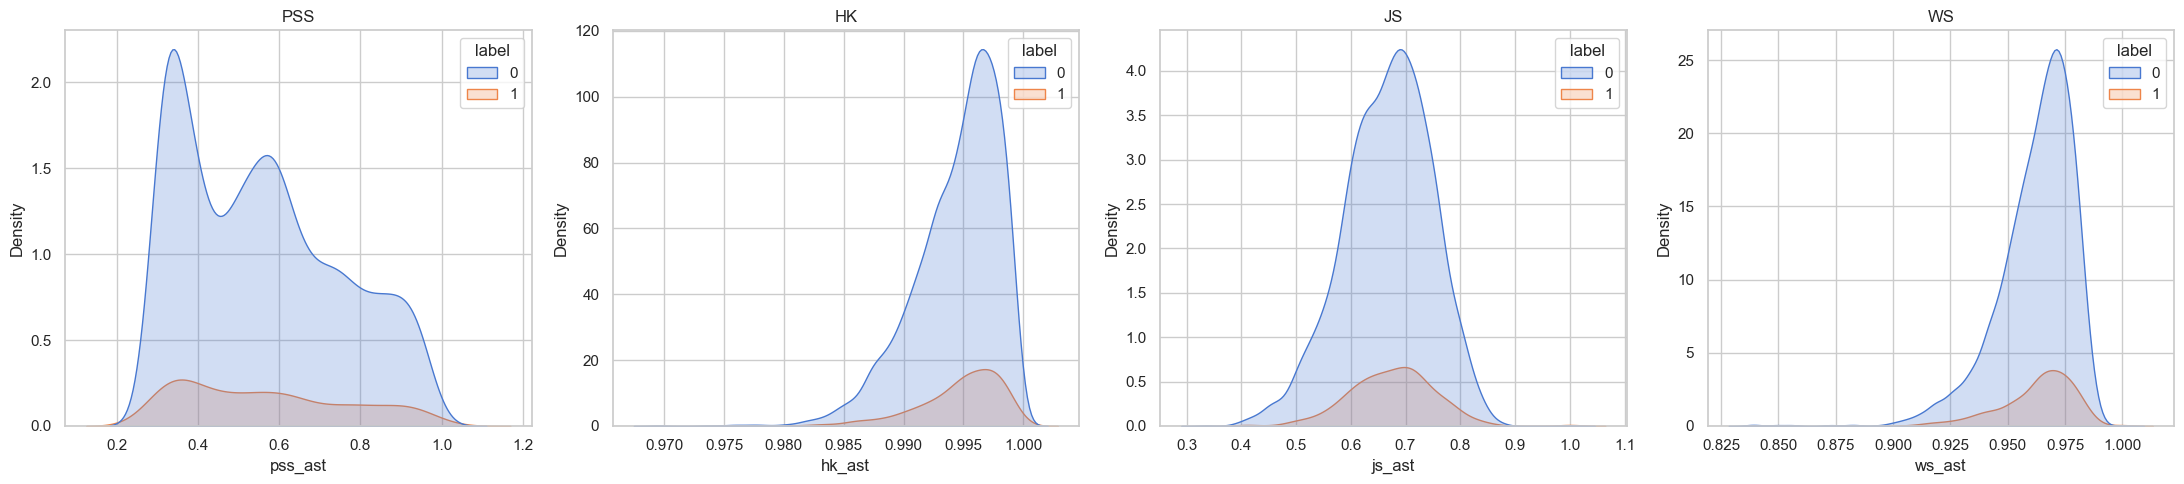

In [6]:
plot_layer_analysis("ast")


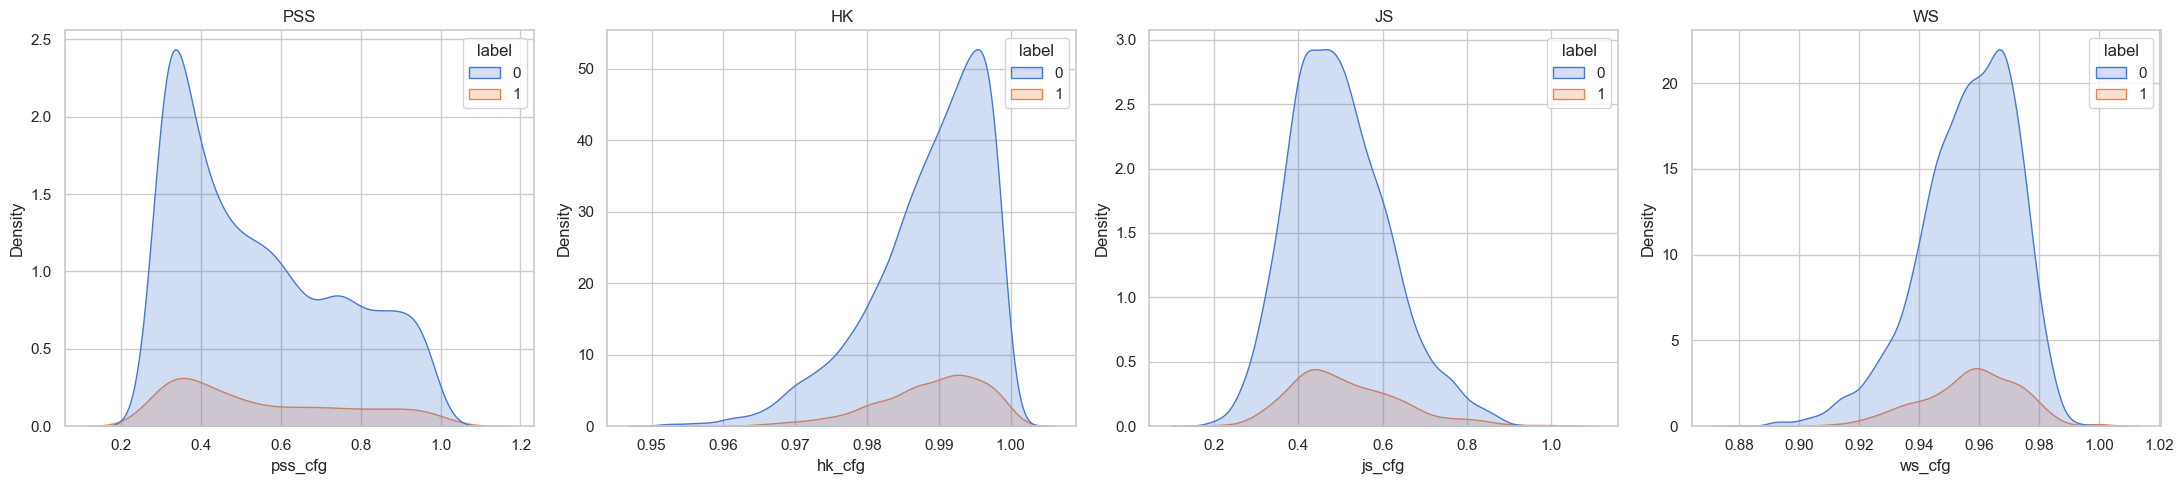

In [7]:
plot_layer_analysis("cfg")


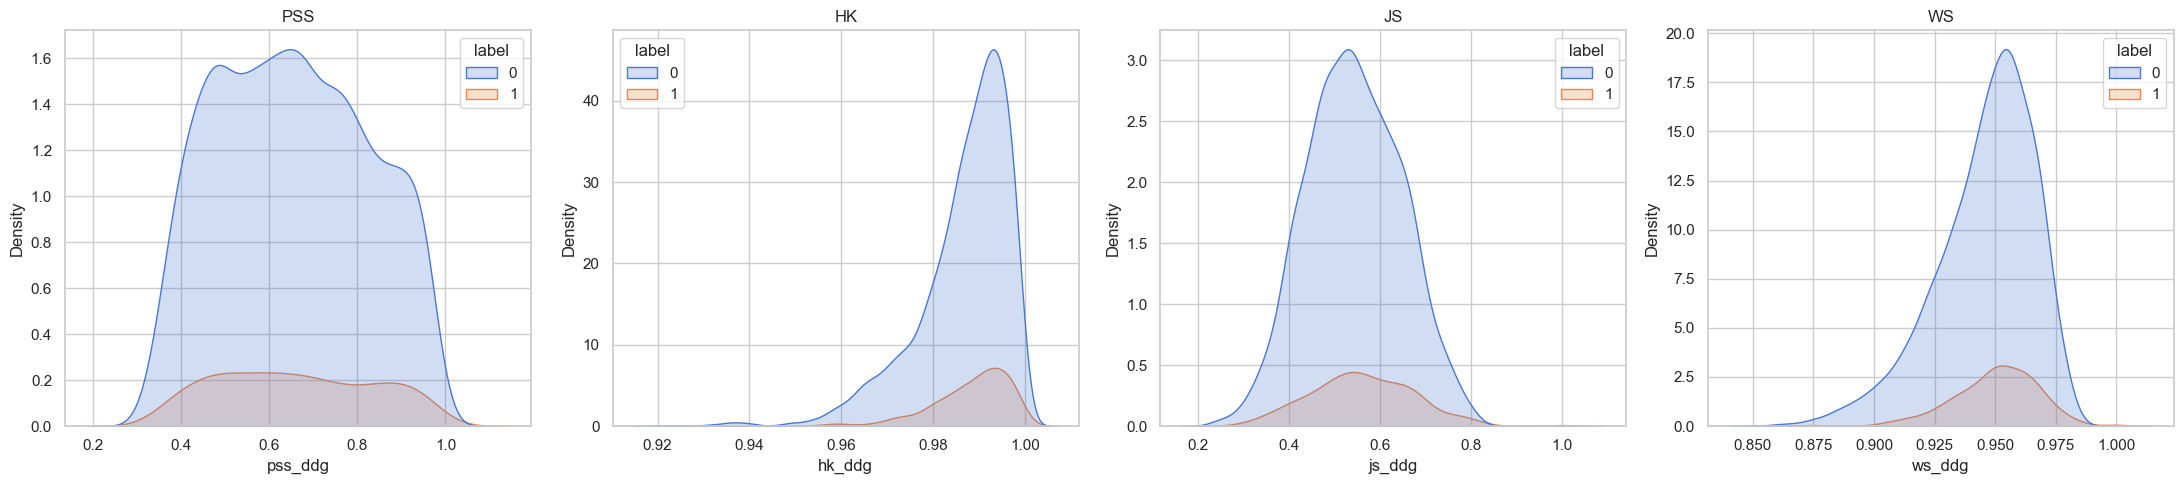

In [8]:
plot_layer_analysis("ddg")


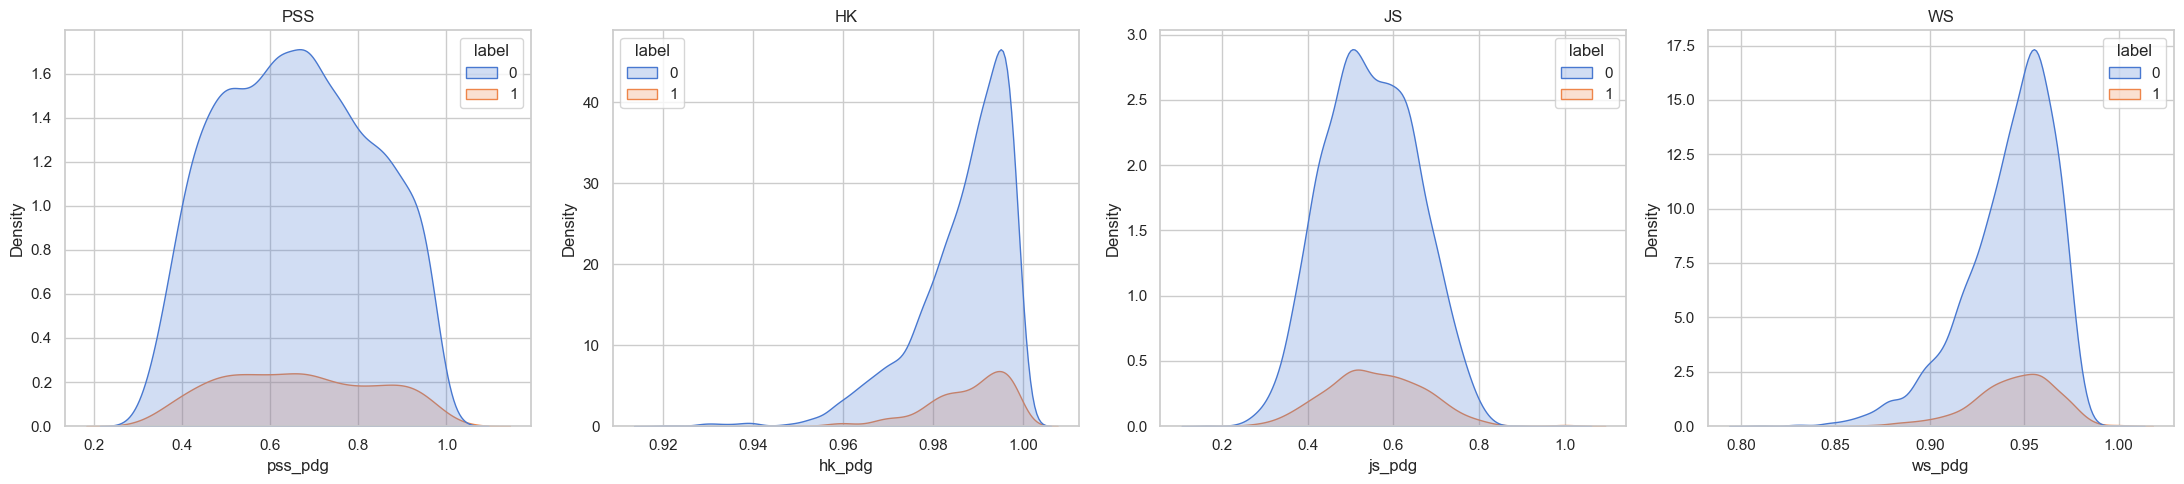

In [9]:
plot_layer_analysis("pdg")


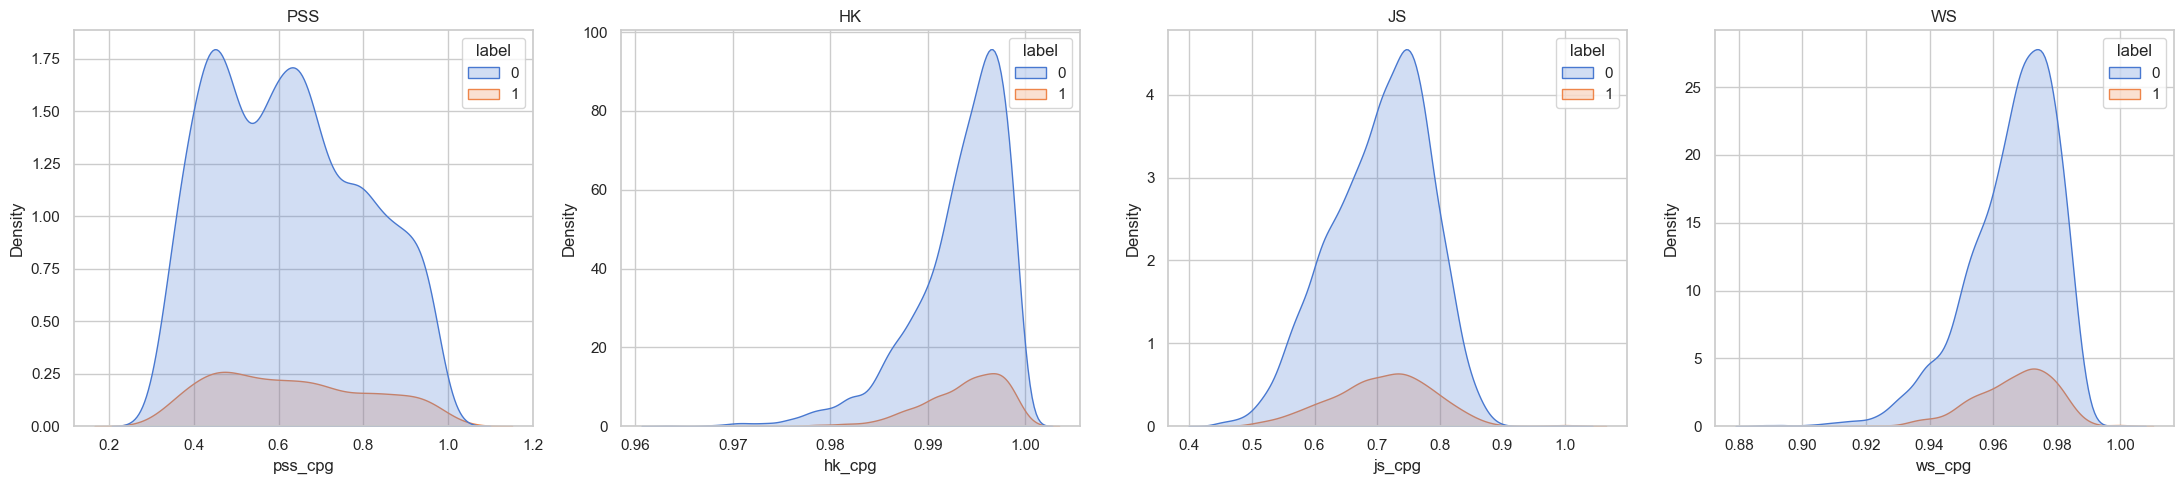

In [10]:
plot_layer_analysis("cpg")
